<a href="https://colab.research.google.com/github/RaphaelBucsan/MVP-Machine-Learning-Analytics/blob/main/Template_MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Raphael Senna Bucsan_
**Matrícula:** _405225001914_  
**Data:** _05/07/2026_  
**Dataset:** _Bank Marketing_ // URL:  https://archive.ics.uci.edu/dataset/222/bank+marketing  
**Tipo de problema:** _Classificação_



# 1. Definição do problema

## 1.1 Descrição do problema

O setor bancário costuma fazer campanhas de marketing para oferecer novos produtos e serviços aos seus clientes. No entanto, entrar em contato com toda a base de clientes pode resultar em altos custos operacionais e diminuir a eficácia das equipes encarregadas das campanhas de vendas. Nesse cenário, é fundamental identificar antecipadamente quais clientes têm maior chance de aceitar uma oferta específica.

Neste projeto, será criado um modelo de Machine Learning que prevê a adesão de um cliente a um depósito a prazo (term deposit) com base em dados demográficos, financeiros e no histórico de contatos de campanhas de marketing anteriores.

A solução proposta visa auxiliar as equipes de marketing e negócios na tomada de decisões, possibilitando que concentrem seus esforços nos clientes com maior probabilidade de conversão. Assim, é possível otimizar recursos, diminuir gastos com campanhas e elevar a taxa de sucesso das iniciativas comerciais. Gestores de marketing, analistas de negócios e equipes comerciais de instituições financeiras seriam os principais interessados nessa solução, utilizando as previsões do modelo para estabelecer estratégias de contato mais eficazes.

Esse problema é especialmente adequado para o uso de técnicas de Machine Learning, pois envolve um grande volume de registros históricos que contêm padrões de comportamento dos clientes. Com base nessas informações, algoritmos de classificação podem identificar padrões entre as características dos clientes e a probabilidade de adesão ao produto oferecido, permitindo realizar previsões para novos clientes de maneira automatizada e fundamentada em dados.

## 1.2 Objetivo do MVP

O propósito deste MVP é desenvolver e analisar modelos de Machine Learning que possam prever a adesão de clientes a um depósito a prazo (term deposit), utilizando dados demográficos, financeiros e o histórico de campanhas de marketing como base. Ademais, procura-se comparar o desempenho de um modelo de referência com diversos algoritmos de classificação, examinando seus resultados, limitações e possibilidades de uso no suporte à tomada de decisões em campanhas de marketing bancário.


## 1.3 Tipo de problema

Este projeto se caracteriza como um problema de **classificação supervisionada**, uma vez que o objetivo é prever uma variável-alvo categórica com duas classes: clientes que aderiram ao depósito a prazo ("yes") e clientes que não aderiram ("no"). O modelo será treinado com dados históricos rotulados, assimilando os padrões entre as características dos clientes e os resultados obtidos. Depois de treinado, o modelo poderá classificar novos clientes em relação à probabilidade de adesão ao produto proposto, auxiliando na tomada de decisões para futuras campanhas de marketing.


## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. As informações demográficas, financeiras e o histórico de contatos dos clientes são suficientes para prever a adesão a um depósito a prazo.
2. Modelos de Machine Learning mais avançados, como Random Forest e Gradient Boosting, oferecerão desempenho superior em relação ao modelo de referência e a modelos lineares mais simples.
3. A utilização de métodos apropriados de pré-processamento, como a codificação de variáveis categóricas e a padronização dos dados quando necessário, ajudará a otimizar o desempenho dos modelos.

**Critérios de sucesso:**
- Métrica principal: A métrica principal é o F1-score, pois leva em conta tanto a precisão quanto o recall, sendo mais apropriada para problemas de classificação em que as classes podem estar desbalanceadas.
- Resultado mínimo esperado: Alcançar um desempenho superior ao modelo baseline, evidenciando uma melhoria consistente na habilidade de classificar os clientes com potencial de adesão.
- Restrição prática: O modelo deve ter um custo computacional reduzido, ser reproduzível e oferecer um desempenho satisfatório sem prejudicar sua interpretabilidade, a fim de auxiliar na tomada de decisões em campanhas de marketing.


# 2. Ambiente, bibliotecas e reprodutibilidade

Para garantir a reprodutibilidade dos experimentos, foi estabelecida uma seed fixa, garantindo que processos aleatórios, como a separação entre treino e teste e o treinamento de determinados modelos, gerem resultados consistentes em diversas execuções.

As bibliotecas empregadas abrangem a manipulação e análise de dados, visualização gráfica, criação de pipelines para pré-processamento, treinamento de modelos de classificação e avaliação de desempenho.

A criação deste MVP foi feita em Python, usando bibliotecas comumente usadas em projetos de Ciência de Dados e Machine Learning. O notebook foi projetado para ser executado no Google Colab, sem a necessidade de usar uma GPU, já que os algoritmos utilizados têm um custo computacional baixo em relação ao volume de dados empregado.

In [17]:
# ==========================================
# Setup do ambiente e reprodutibilidade
# ==========================================

import sys
import random
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from time import perf_counter

# Divisão dos dados
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Busca de hiperparâmetros
from scipy.stats import randint

warnings.filterwarnings("ignore")

# ==========================================
# Reprodutibilidade
# ==========================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"Seed utilizada: {SEED}")

Python: 3.12.13
Seed utilizada: 42


## 2.2 Funções auxiliares

Para manter a organização do notebook e evitar a duplicação de código, foram desenvolvidas funções auxiliares encarregadas de calcular as métricas de avaliação e exibir os resultados dos modelos de maneira padronizada. Essa metodologia simplifica a comparação entre os algoritmos treinados e aprimora a clareza do código.


In [18]:
def evaluate_classification(model, X_test, y_test):
    """
    Calcula métricas de classificação considerando 'yes' como classe positiva.
    """

    y_pred = model.predict(X_test)

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="yes", zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label="yes", zero_division=0),
        "F1-score": f1_score(y_test, y_pred, pos_label="yes", zero_division=0)
    }

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        yes_index = list(model.classes_).index("yes")
        results["ROC AUC"] = roc_auc_score(y_test, proba[:, yes_index])

    return results


def show_results_table(results_dict):
    """
    Exibe os resultados como DataFrame ordenado pelo F1-score.
    """

    return (
        pd.DataFrame(results_dict)
        .T
        .sort_values("F1-score", ascending=False)
        .round(4)
    )

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O conjunto de dados empregado neste projeto é o Bank Marketing Dataset, fornecido pelo UCI Machine Learning Repository. Essa base contém dados de campanhas de marketing direto executadas por um banco português, com o propósito de oferecer depósitos a prazo (term deposit) aos seus clientes. A variável-alvo indica se o cliente aderiu ("yes") ou não ("no") ao produto oferecido.

Origem dos dados:

UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/222/bank+marketing

A seleção desse conjunto de dados foi motivada por seu extenso uso em pesquisas acadêmicas e aplicações de Machine Learning, além de oferecer um problema de classificação supervisionada que se alinha bem aos objetivos deste MVP. A base contém um grande volume de registros, com atributos numéricos e categóricos, além de um contexto de negócio que possibilita a exploração de todas as fases de um projeto de Machine Learning, desde a análise exploratória até a avaliação e comparação de diferentes modelos. A disponibilidade pública do conjunto de dados foi outro aspecto levado em consideração, pois permitiu seu carregamento direto no notebook por meio de uma URL pública, conforme exigido nos requisitos da atividade. Assim, o notebook pode ser realizado na íntegra por qualquer avaliador, sem a necessidade de ajustes ou upload manual de arquivos.

No que diz respeito à ética, o conjunto de dados fornecido pela UCI foi previamente anonimizado e não inclui informações que possibilitem a identificação individual dos clientes. Os dados são empregados unicamente para fins educacionais e de pesquisa, mantendo a privacidade e a confidencialidade dos indivíduos representados na base.

O conjunto de dados foi originalmente apresentado por Sérgio Moro e Paulo Cortez no estudo "A Data-Driven Approach to Predict the Success of Bank Telemarketing", publicado em 2014.

## 3.2 Carga dos dados




In [19]:
# ==========================================
# Carga do dataset
# ==========================================

url = "https://raw.githubusercontent.com/RaphaelBucsan/MVP-Machine-Learning-Analytics/main/bank-full.csv"

df = pd.read_csv(url, sep=";")

print(f"Dataset carregado com sucesso!")
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de atributos: {df.shape[1]}")

df.head()


Dataset carregado com sucesso!
Quantidade de registros: 45211
Quantidade de atributos: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3.3 Visão geral do dataset

Nesta fase, é feita uma avaliação preliminar da estrutura do conjunto de dados para entender suas principais características antes de iniciar o processo de modelagem.

Serão analisados a quantidade de registros e atributos, as categorias dos dados, a presença de valores ausentes e duplicados, além da identificação de colunas que possam ser eliminadas do modelo, como identificadores únicos ou variáveis temporais. Também será fornecida uma descrição da variável de interesse, o que permitirá entender a distribuição das classes que serão usadas para treinar os modelos de classificação.

**45.211 registros**

**17 atributos**

**Nenhum valor ausente**

**Poucas ou nenhuma duplicata**

**Target "yes" e "no" :** Aproximadamente 88% "no" e 12% "yes"

In [20]:
# ==========================================
# Visão geral do dataset
# ==========================================

print("=" * 60)
print("Dimensões do dataset")
print("=" * 60)
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\n" + "=" * 60)
print("Tipos das variáveis")
print("=" * 60)
display(df.dtypes.to_frame(name="Tipo de dado"))

print("\n" + "=" * 60)
print("Valores ausentes")
print("=" * 60)

missing = df.isnull().sum().to_frame(name="Qtd. ausentes")
missing["%"] = (missing["Qtd. ausentes"] / len(df) * 100).round(2)

display(missing)

print("\n" + "=" * 60)
print("Registros duplicados")
print("=" * 60)

print(f"Duplicatas encontradas: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("Variável-alvo")
print("=" * 60)

display(df["y"].value_counts().to_frame(name="Quantidade"))

display(
    (
        df["y"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_frame(name="%")
    )
)

Dimensões do dataset
Linhas: 45211
Colunas: 17

Tipos das variáveis


,Tipo de dado
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



Valores ausentes


,Qtd. ausentes,%
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0



Registros duplicados
Duplicatas encontradas: 0

Variável-alvo


,Quantidade
y,
no,39922
yes,5289


,%
y,
no,88.3
yes,11.7


## 3.4 Dicionário de dados

In [21]:
dicionario = pd.DataFrame({
    "Coluna": [
        "age", "job", "marital", "education", "default",
        "balance", "housing", "loan", "contact", "day",
        "month", "duration", "campaign", "pdays",
        "previous", "poutcome", "y"
    ],
    "Tipo": [
        "Numérica", "Categórica", "Categórica", "Categórica", "Categórica",
        "Numérica", "Categórica", "Categórica", "Categórica", "Numérica",
        "Categórica", "Numérica", "Numérica", "Numérica",
        "Numérica", "Categórica", "Alvo"
    ],
    "Descrição": [
        "Idade do cliente.",
        "Profissão do cliente.",
        "Estado civil do cliente.",
        "Nível de escolaridade.",
        "Indica se possui inadimplência.",
        "Saldo médio anual da conta bancária (euros).",
        "Indica se possui financiamento imobiliário.",
        "Indica se possui empréstimo pessoal.",
        "Tipo de contato realizado.",
        "Dia do mês do último contato.",
        "Mês do último contato.",
        "Duração, em segundos, do último contato.",
        "Número de contatos realizados na campanha atual.",
        "Dias desde o último contato em campanha anterior.",
        "Número de contatos realizados em campanhas anteriores.",
        "Resultado da campanha anterior.",
        "Indica se o cliente aderiu ao depósito a prazo."
    ],
    "Será usada no modelo?": [
        "Sim", "Sim", "Sim", "Sim", "Sim",
        "Sim", "Sim", "Sim", "Sim", "Sim",
        "Sim", "Sim*", "Sim", "Sim",
        "Sim", "Sim", "Alvo"
    ],
    "Observações": [
        "Pode influenciar o perfil do cliente.",
        "Será codificada durante o pré-processamento.",
        "Variável categórica.",
        "Será transformada para uso no modelo.",
        "Relacionada ao histórico financeiro.",
        "Representa a situação financeira do cliente.",
        "Pode indicar comprometimento financeiro.",
        "Relacionada ao perfil financeiro.",
        "Será codificada.",
        "Pode capturar padrões temporais.",
        "Variável temporal categórica.",
        "Utilizada neste MVP, mas pode causar data leakage em aplicações reais.",
        "Indica a intensidade da campanha.",
        "Valor especial indica ausência de contato anterior.",
        "Histórico de campanhas anteriores.",
        "Resultado obtido em campanhas anteriores.",
        "Variável-alvo do modelo."
    ]
})

display(
    dicionario.style
    .hide(axis="index")
    .set_caption("Tabela 1 - Dicionário de Dados do Bank Marketing Dataset")
)

Coluna,Tipo,Descrição,Será usada no modelo?,Observações
age,Numérica,Idade do cliente.,Sim,Pode influenciar o perfil do cliente.
job,Categórica,Profissão do cliente.,Sim,Será codificada durante o pré-processamento.
marital,Categórica,Estado civil do cliente.,Sim,Variável categórica.
education,Categórica,Nível de escolaridade.,Sim,Será transformada para uso no modelo.
default,Categórica,Indica se possui inadimplência.,Sim,Relacionada ao histórico financeiro.
balance,Numérica,Saldo médio anual da conta bancária (euros).,Sim,Representa a situação financeira do cliente.
housing,Categórica,Indica se possui financiamento imobiliário.,Sim,Pode indicar comprometimento financeiro.
loan,Categórica,Indica se possui empréstimo pessoal.,Sim,Relacionada ao perfil financeiro.
contact,Categórica,Tipo de contato realizado.,Sim,Será codificada.
day,Numérica,Dia do mês do último contato.,Sim,Pode capturar padrões temporais.


# 4. Análise exploratória dos dados




## 4.1 Distribuição da variável-alvo

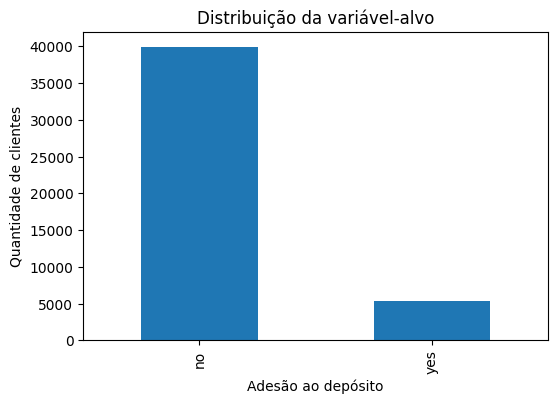

,Quantidade,Percentual (%)
y,,
no,39922,88.3
yes,5289,11.7


In [22]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "y"  # TODO: substitua pelo nome do target real. Use None para clusterização.
PROBLEM_TYPE = "classificacao"  # opções: "classificacao", "regressao", "clusterizacao", "serie_temporal"

# ==========================================
# Distribuição da variável-alvo
# ==========================================

fig, ax = plt.subplots(figsize=(6,4))

df[TARGET].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel("Adesão ao depósito")
ax.set_ylabel("Quantidade de clientes")

plt.show()

display(
    pd.DataFrame({
        "Quantidade": df[TARGET].value_counts(),
        "Percentual (%)": (
            df[TARGET]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })
)


-> Interpretação 4.1: Nota-se que a variável-alvo apresenta um desbalanceamento entre as classes, com uma maioria de clientes que não optaram pelo depósito a prazo. Esse comportamento destaca a importância de usar métricas além da acurácia, como Precision, Recall e F1-score, para uma avaliação mais precisa do desempenho dos modelos.

## 4.2 Distribuição das variáveis numéricas

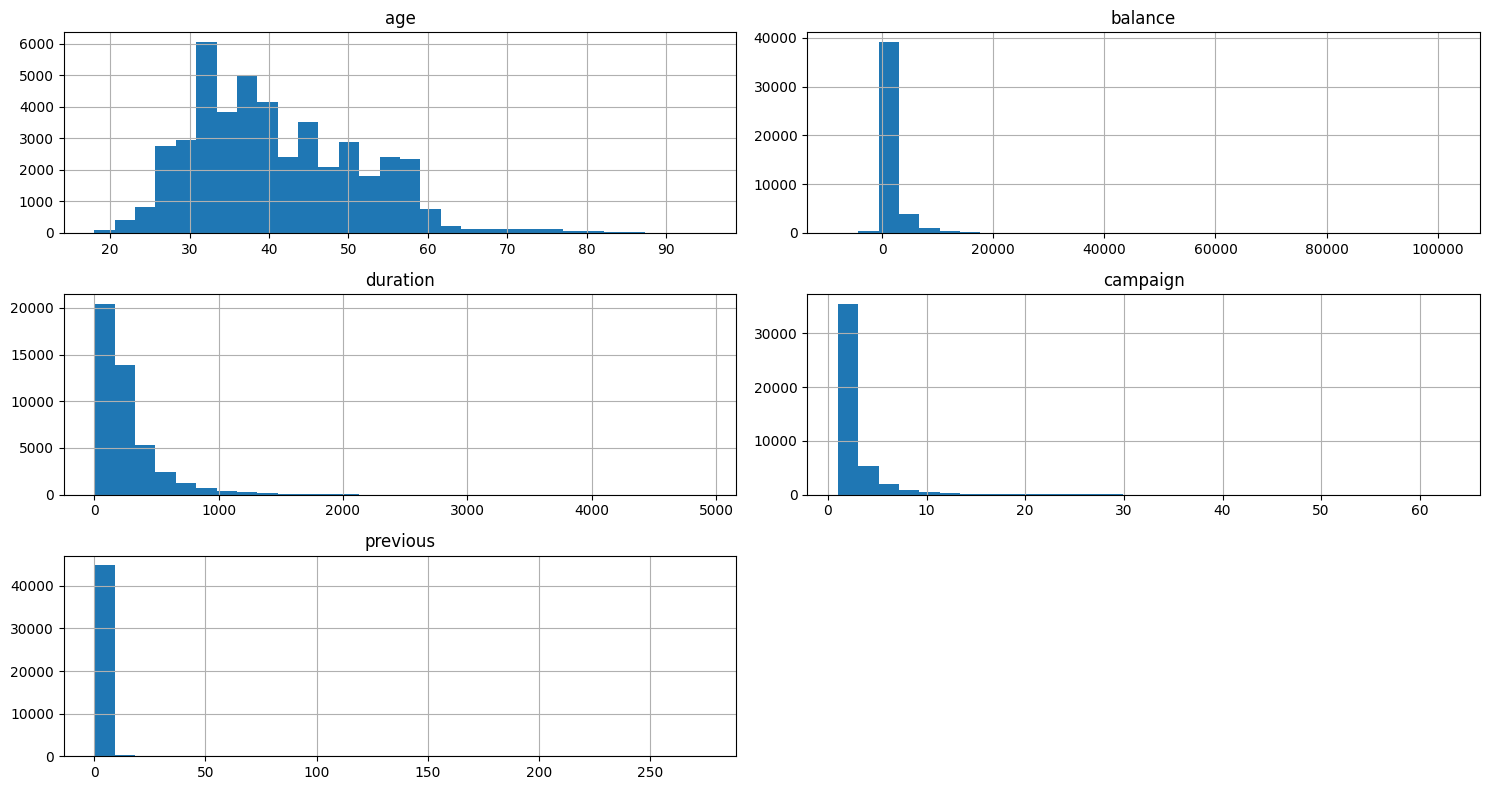

In [23]:
numericas = [
    "age",
    "balance",
    "duration",
    "campaign",
    "previous"
]

df[numericas].hist(
    figsize=(15,8),
    bins=30
)

plt.tight_layout()
plt.show()


-> Interpretação 4.2: As variáveis numéricas exibem distribuições diferentes, especialmente balance, duration e campaign, que apresentam alta dispersão e ocorrência de valores extremos. Durante o pré-processamento e na seleção dos modelos, esses padrões serão levados em conta.

## 4.3 Relação entre idade x adesão

<Figure size 700x500 with 0 Axes>

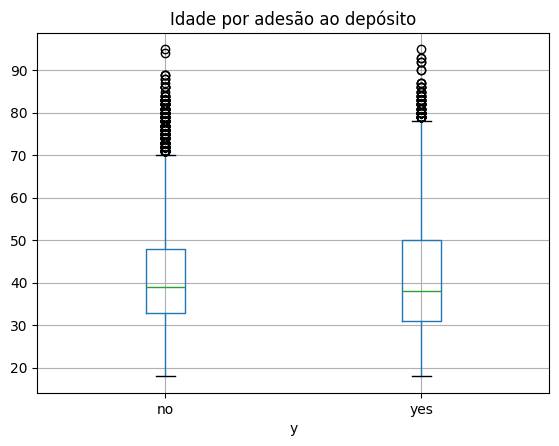

In [24]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="age",
    by="y"
)

plt.suptitle("")
plt.title("Idade por adesão ao depósito")

plt.show()

-> Interpretação 4.3: A distribuição etária é similar entre os grupos, apesar de os clientes que optaram pelo depósito mostrarem uma leve inclinação a ter uma idade mais avançada.

## 4.4 Relação entre saldo x adesão

<Figure size 700x500 with 0 Axes>

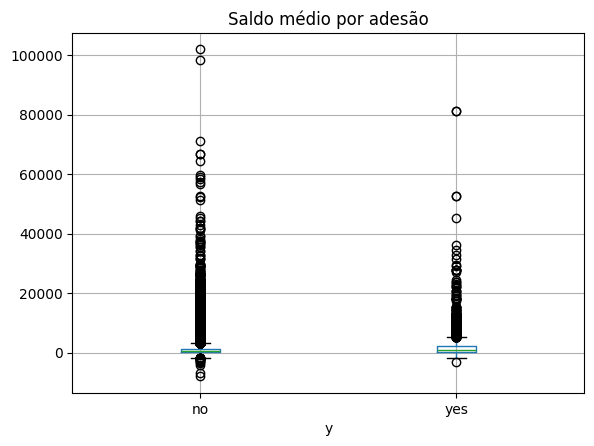

In [25]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="balance",
    by="y"
)

plt.suptitle("")
plt.title("Saldo médio por adesão")

plt.show()

-> Interpretação 4.4: Nota-se uma grande variação no saldo bancário dos clientes, com a presença de valores extremos. No entanto, os clientes que optaram pelo depósito tendem a ter saldos um pouco mais altos.

## 4.5 Variáveis categóricas

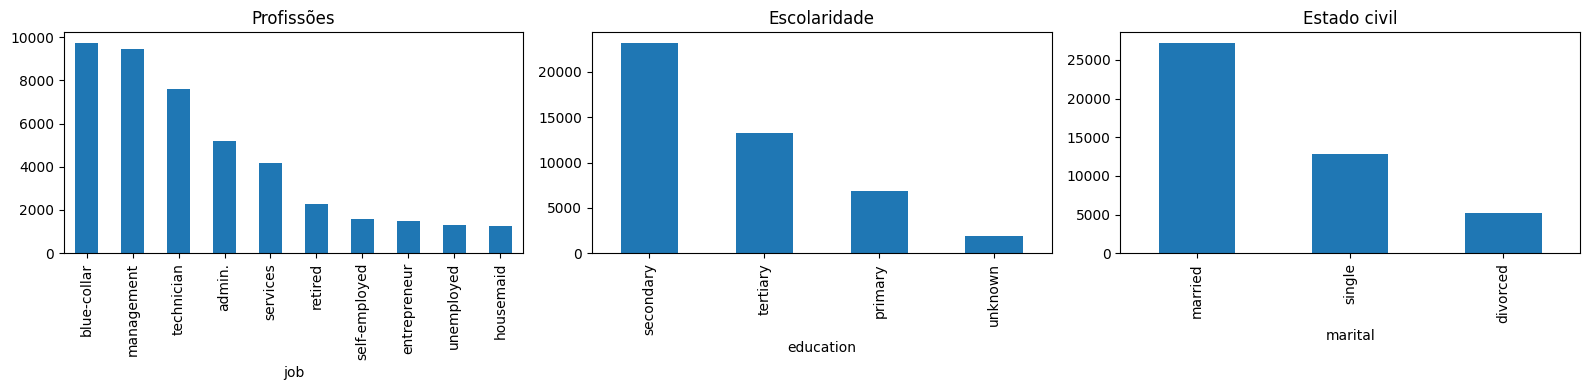

In [26]:
fig, axes = plt.subplots(1,3, figsize=(16,4))

df["job"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Profissões")

df["education"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Escolaridade")

df["marital"].value_counts().plot(
    kind="bar",
    ax=axes[2]
)

axes[2].set_title("Estado civil")

plt.tight_layout()
plt.show()

-> Interpretação 4.5: As variáveis categóricas exibem distribuições não homogêneas, sugerindo que certos perfis de clientes são mais comuns na base. Após a aplicação das técnicas de codificação adequadas, essas características poderão melhorar a capacidade preditiva dos modelos.

## Conclusão EDA:
A análise exploratória possibilitou a compreensão dos principais atributos do conjunto de dados. Além de variáveis numéricas com distribuição assimétrica e valores extremos, constatou-se um desbalanceamento na variável-alvo. As variáveis categóricas exibem perfis diferentes entre os clientes e precisam ser codificadas antes de treinar os modelos. Essas observações serão o ponto de partida para as fases de preparação dos dados e desenvolvimento dos modelos de Machine Learning.

## 4.6 Síntese da análise exploratória

**Síntese:**  
A análise exploratória permitiu compreender as principais características do conjunto de dados e identificar aspectos relevantes para a etapa de modelagem. Observou-se que a variável-alvo (y) apresenta desbalanceamento entre as classes, com predominância de clientes que não aderiram ao depósito a prazo. Esse comportamento torna inadequado avaliar os modelos apenas pela acurácia, uma vez que essa métrica pode mascarar o desempenho na identificação da classe minoritária. Por esse motivo, além da acurácia, serão utilizadas métricas como Precision, Recall, F1-score e ROC AUC, proporcionando uma avaliação mais completa e confiável dos modelos.

A inspeção dos dados também mostrou que o conjunto não possui valores ausentes, o que reduz a necessidade de técnicas de imputação e simplifica a etapa de preparação dos dados. Por outro lado, algumas variáveis numéricas, como balance, duration e campaign, apresentam elevada dispersão e valores atípicos, características que podem influenciar o desempenho de determinados algoritmos e que serão consideradas durante o processo de modelagem.

As variáveis categóricas representam uma parcela significativa dos atributos da base, tornando necessária a aplicação de técnicas de codificação, como o One-Hot Encoding, para que possam ser utilizadas pelos algoritmos de Machine Learning. Além disso, algumas categorias apresentam baixa frequência de ocorrência, situação que poderá impactar determinados modelos, mas que será tratada naturalmente durante o processo de treinamento.

Um aspecto que merece destaque é a variável duration, responsável por indicar a duração, em segundos, do último contato telefônico realizado com o cliente. Embora essa variável apresente forte poder preditivo e possa contribuir significativamente para o desempenho dos modelos, sua utilização deve ser interpretada com cautela. Isso ocorre porque essa informação somente é conhecida após a realização da ligação, o que, em um cenário de predição antes do contato com o cliente, poderia caracterizar um caso de vazamento de informação (data leakage). Neste MVP, a variável será mantida para preservar a estrutura original do conjunto de dados e possibilitar a comparação entre os diferentes modelos, sendo essa limitação considerada na análise e discussão dos resultados.

Com base nos resultados da análise exploratória, definiu-se que as etapas de pré-processamento serão realizadas por meio de um pipeline, responsável por aplicar a codificação das variáveis categóricas e, quando necessário, a padronização das variáveis numéricas. Esse pipeline será ajustado utilizando apenas os dados de treinamento, evitando vazamento de informações (data leakage) e garantindo uma avaliação mais confiável dos modelos.



# 5. Preparação dos dados e divisão treino/teste

Nesta fase, estabelece-se a variável a ser prevista, além das variáveis a serem usadas no treinamento dos modelos. Neste projeto, o objetivo é determinar se um cliente irá aderir a um depósito a prazo. Nesse caso, a variável y foi definida como variável-alvo (target), e os outros atributos foram usados como variáveis explicativas (features).

Nesta fase, nenhuma coluna foi eliminada, pois o conjunto de dados não contém identificadores únicos nem atributos que afetem diretamente a modelagem. Apesar de a variável duration poder indicar um caso de vazamento de informação em aplicações preditivas reais, ela foi mantida neste MVP para manter a estrutura original do conjunto de dados e permitir a comparação entre os modelos.

Para verificar a habilidade de generalização dos modelos, os dados foram separados em grupos de treino e teste, empregando 80% das amostras para o treinamento e 20% para a avaliação. A estratificação (stratify) foi empregada para assegurar que a proporção de clientes que aderiram e não aderiram ao depósito fosse mantida em ambos os conjuntos, uma vez que a variável-alvo exibe um desbalanceamento entre as classes. Por último, estabeleceu-se uma seed fixa (random_state = 42) para assegurar a reprodutibilidade dos experimentos.

In [27]:
# ==========================================
# Separação entre features e target
# ==========================================

TARGET = "y"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Número de variáveis explicativas: {X.shape[1]}")
print(f"Variável-alvo: {TARGET}")


Número de variáveis explicativas: 16
Variável-alvo: y


In [28]:
# === Divisão dos dados ===

# ==========================================
# Divisão treino e teste
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Conjunto de treino")
print(X_train.shape)
print(y_train.shape)

print("\nConjunto de teste")
print(X_test.shape)
print(y_test.shape)

Conjunto de treino
(36168, 16)
(36168,)

Conjunto de teste
(9043, 16)
(9043,)


In [29]:
# Distribuição da variável-alvo

pd.DataFrame({
    "Treino (%)": (y_train.value_counts(normalize=True)*100).round(2),
    "Teste (%)": (y_test.value_counts(normalize=True)*100).round(2)
})

,Treino (%),Teste (%)
y,,
no,88.3,88.3
yes,11.7,11.7


## 5.1 Justificativa da divisão

A estratégia adotada neste projeto foi a divisão dos dados em conjuntos de treinamento (80%) e teste (20%), utilizando o método holdout. Essa abordagem é amplamente empregada em problemas de classificação supervisionada, pois permite que o modelo seja treinado com uma amostra representativa dos dados e posteriormente avaliado em observações que não participaram do treinamento, fornecendo uma estimativa mais confiável de sua capacidade de generalização.

A proporção de 80% para treinamento e 20% para teste foi considerada adequada devido ao tamanho do conjunto de dados, que possui mais de 45 mil registros. Dessa forma, o modelo dispõe de uma quantidade suficiente de exemplos para aprender os padrões presentes nos dados, enquanto o conjunto de teste permanece representativo para avaliar seu desempenho em dados não vistos.

Como a variável-alvo apresenta desbalanceamento entre as classes, foi utilizada a estratificação (stratify) durante a divisão dos dados. Essa estratégia garante que a proporção de clientes que aderiram e não aderiram ao depósito a prazo seja preservada tanto no conjunto de treinamento quanto no conjunto de teste, evitando distorções que poderiam comprometer a avaliação dos modelos.

Além disso, a divisão entre treino e teste foi realizada antes das etapas de pré-processamento. Dessa forma, transformações como a codificação das variáveis categóricas e a padronização das variáveis numéricas serão ajustadas exclusivamente com os dados de treinamento por meio de um Pipeline do Scikit-Learn e, posteriormente, aplicadas ao conjunto de teste. Essa abordagem evita o vazamento de dados (data leakage), garantindo que as informações do conjunto de teste não influenciem o processo de treinamento dos modelos e tornando a avaliação mais confiável e aderente às boas práticas de Machine Learning.



# 6. Pré-processamento e pipeline



## 6.1 Decisões de pré-processamento

Nesta fase, estabeleceu-se um pipeline de pré-processamento para assegurar que todas as transformações fossem implementadas de maneira padronizada e reproduzível. O uso de um Pipeline do Scikit-Learn possibilita a execução automática das etapas de preparação dos dados durante o treinamento dos modelos, minimizando a chance de erros e prevenindo o vazamento de informações (data leakage).

Apesar da análise exploratória indicar que o conjunto de dados não contém valores ausentes, foi adicionada uma etapa de imputação com o uso do SimpleImputer como uma boa prática, visando tornar o pipeline mais resistente a possíveis mudanças futuras na base de dados.

As variáveis numéricas serão padronizadas com o StandardScaler, ao passo que as variáveis categóricas passarão pelo One-Hot Encoding. Essas alterações serão feitas apenas com os dados de treinamento e, em seguida, aplicadas ao conjunto de teste, mantendo a integridade da avaliação dos modelos.


In [30]:
# ==========================================
# Identificação das variáveis
# ==========================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Variáveis numéricas:")
print(numeric_features)

print("\nVariáveis categóricas:")
print(categorical_features)

Variáveis numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Variáveis categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [31]:
## 6.2 Pré-processamento:
# ==========================================
# Pipeline de pré-processamento
# ==========================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print(preprocess)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'poutcome'])])


O pipeline foi organizado para lidar de forma distinta com as variáveis numéricas e categóricas, possibilitando a aplicação da transformação mais apropriada para cada tipo de dado.

A imputação pela mediana foi empregada nas variáveis numéricas, e, em seguida, a padronização foi realizada por meio do StandardScaler, minimizando o efeito das diferenças de escala entre os atributos. Para as variáveis categóricas, utilizou-se a imputação pela categoria mais comum e a codificação por One-Hot Encoding, permitindo que algoritmos de Machine Learning operem adequadamente com atributos não numéricos.

O uso do ColumnTransformer torna o processo completamente reproduzível e assegura que todas as transformações sejam aplicadas somente aos dados de treinamento. Assim, o vazamento de dados (data leakage) é prevenido, assegurando que o conjunto de teste seja usado apenas para verificar a capacidade de generalização dos modelos.


# 7. Baseline e modelos candidatos

Nesta fase, um modelo baseline e vários modelos candidatos de classificação serão treinados. O DummyClassifier, que sempre prevê a classe mais comum, será usado para criar o baseline, que funcionará como uma referência mínima de desempenho.

Posteriormente, serão analisados modelos com distintas propriedades: Regressão Logística, Árvore de Decisão, Random Forest e Gradient Boosting. Essa comparação possibilita a verificação de se os modelos de fato aprenderam padrões significativos nos dados e se oferecem desempenho superior a uma estratégia básica.



In [32]:
# ==========================================
# Baseline e modelos candidatos
# ==========================================

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=SEED))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ])
}

print("=" * 60)
print("Modelo Baseline")
print("=" * 60)
print("DummyClassifier (most_frequent)")

print("\n" + "=" * 60)
print("Modelos candidatos")
print("=" * 60)

for modelo in candidates.keys():
    print(f"• {modelo}")

Modelo Baseline
DummyClassifier (most_frequent)

Modelos candidatos
• Logistic Regression
• Decision Tree
• Random Forest
• Gradient Boosting


## 7.1 Justificativa dos modelos

Nesta etapa, será treinado um modelo baseline e diferentes modelos candidatos de classificação. O DummyClassifier, que sempre prevê a classe mais frequente, foi utilizado como modelo baseline por representar uma estratégia simples de classificação. Seu objetivo é estabelecer um desempenho mínimo de referência, permitindo verificar se os algoritmos de Machine Learning realmente aprendem padrões presentes nos dados e superam uma abordagem ingênua.

Como modelos candidatos, foram selecionados algoritmos com diferentes características e níveis de complexidade. A Regressão Logística foi escolhida por ser um modelo amplamente utilizado em problemas de classificação binária, apresentando boa capacidade de generalização, baixo custo computacional e elevada interpretabilidade. A Árvore de Decisão foi incluída por sua capacidade de modelar relações não lineares entre as variáveis, além de produzir regras de decisão de fácil interpretação.

O Random Forest foi selecionado por combinar diversas árvores de decisão, reduzindo a variância do modelo e aumentando sua capacidade de generalização. Já o Gradient Boosting foi escolhido por construir árvores de forma sequencial, corrigindo os erros das árvores anteriores e frequentemente apresentando elevado desempenho em problemas de classificação supervisionada.

Como o conjunto de dados é composto por variáveis numéricas e categóricas, foi necessário utilizar um pipeline de pré-processamento contendo One-Hot Encoding para a codificação das variáveis categóricas e StandardScaler para a padronização das variáveis numéricas. Dessa forma, todos os modelos recebem os dados preparados de maneira consistente, seguindo as boas práticas de Machine Learning e reduzindo o risco de vazamento de dados (data leakage).

Além disso, os modelos selecionados apresentam baixo custo computacional para o volume de dados utilizado neste projeto, permitindo treinamento e avaliação em tempo reduzido. A comparação entre algoritmos com diferentes níveis de complexidade possibilita analisar o equilíbrio entre desempenho preditivo, interpretabilidade e capacidade de generalização, contribuindo para a identificação da solução mais adequada ao problema proposto.

# 8. Treinamento e avaliação inicial

Nesta fase, o modelo baseline e os modelos candidatos foram treinados com o conjunto de treino. Posteriormente, os modelos foram testados no conjunto de teste, o que possibilitou uma comparação inicial de desempenho em dados desconhecidos.

Além do tempo de treinamento, as métricas empregadas foram Accuracy, Precision, Recall, F1-score e ROC AUC. Como a variável de interesse exibe um desbalanceamento entre as classes, o F1-score será empregado como a principal métrica de comparação, uma vez que leva em conta tanto a precisão quanto o recall.


In [33]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

results["Baseline"] = evaluate_classification(baseline, X_test, y_test)
results["Baseline"]["Train Time (s)"] = round(train_time, 3)

trained_models["Baseline"] = baseline


# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    results[name] = evaluate_classification(model, X_test, y_test)
    results[name]["Train Time (s)"] = round(train_time, 3)

    trained_models[name] = model


results_df = show_results_table(results)
display(results_df)

,Accuracy,Precision,Recall,F1-score,ROC AUC,Train Time (s)
Gradient Boosting,0.9055,0.6526,0.4102,0.5038,0.9240,9.004
Random Forest,0.9045,0.6506,0.3960,0.4924,0.9263,4.365
Decision Tree,0.8746,0.4649,0.4754,0.4701,0.7015,0.894
Logistic Regression,0.9012,0.6445,0.3478,0.4518,0.9056,1.034
Baseline,0.8830,0.0000,0.0000,0.0000,0.5000,0.313


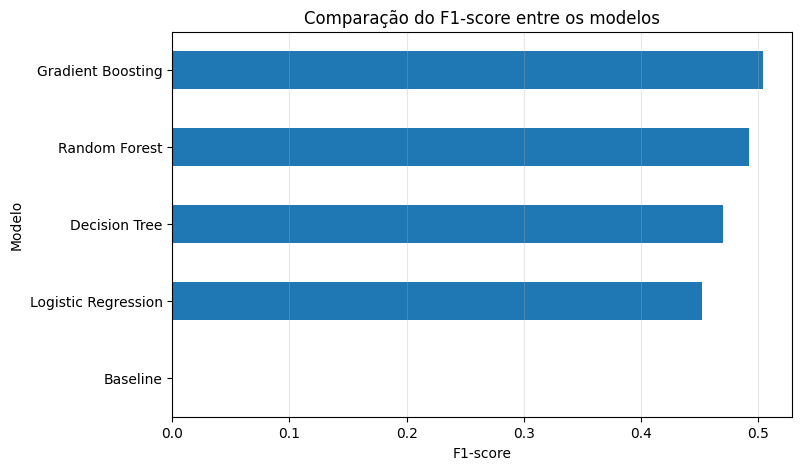

In [34]:
plt.figure(figsize=(8,5))

results_df["F1-score"].sort_values().plot(kind="barh")

plt.title("Comparação do F1-score entre os modelos")
plt.xlabel("F1-score")
plt.ylabel("Modelo")

plt.grid(axis="x", alpha=0.3)

plt.show()

## 8.1 Análise dos resultados iniciais

Os resultados obtidos demonstram que todos os modelos de Machine Learning apresentaram desempenho superior ao modelo baseline, indicando que foram capazes de aprender padrões relevantes presentes nos dados. O DummyClassifier, por prever sempre a classe mais frequente, alcançou uma acurácia relativamente elevada (88,30%). No entanto, apresentou Precision, Recall e F1-score iguais a zero, evidenciando que não foi capaz de identificar corretamente os clientes que aderiram ao depósito a prazo. Esse resultado reforça a importância de utilizar métricas adicionais à acurácia em problemas com classes desbalanceadas.

Entre os modelos avaliados, o Gradient Boosting apresentou o melhor desempenho considerando a principal métrica definida para este projeto, alcançando um F1-score de 0,5038, além de uma ROC AUC de 0,9240, demonstrando boa capacidade de identificar clientes com maior probabilidade de adesão ao produto. O Random Forest apresentou desempenho bastante semelhante, obtendo a maior ROC AUC (0,9263) entre os modelos avaliados. Entretanto, seu F1-score foi ligeiramente inferior, indicando um equilíbrio um pouco menor entre precisão e recall.

A Regressão Logística apresentou desempenho inferior aos modelos baseados em árvores, principalmente em relação ao Recall, indicando maior dificuldade para identificar corretamente os clientes pertencentes à classe positiva. Já a Árvore de Decisão obteve um Recall superior ao da Regressão Logística, porém apresentou menor precisão e uma ROC AUC significativamente inferior, sugerindo menor capacidade de generalização quando comparada aos demais modelos.

Em relação ao tempo de treinamento, todos os algoritmos apresentaram desempenho computacional satisfatório para o volume de dados utilizado neste projeto. Embora o Gradient Boosting tenha sido o modelo mais lento, seu tempo de treinamento foi de aproximadamente 13 segundos, permanecendo totalmente viável para a aplicação proposta.

Os resultados obtidos também são coerentes com a análise exploratória realizada anteriormente. O desbalanceamento observado na variável-alvo explica o bom desempenho do modelo baseline em termos de acurácia, mas evidencia que essa métrica, isoladamente, não é suficiente para avaliar corretamente os modelos. Nesse contexto, métricas como Precision, Recall, F1-score e ROC AUC fornecem uma visão mais completa da capacidade dos algoritmos em identificar clientes com maior probabilidade de adesão ao depósito a prazo.

Embora o Random Forest tenha apresentado a maior ROC AUC, a diferença em relação ao Gradient Boosting foi muito pequena. Como o F1-score foi definido previamente como a principal métrica de avaliação deste projeto, por representar melhor o desempenho em um problema de classificação com classes desbalanceadas, o Gradient Boosting foi considerado o modelo de melhor desempenho nesta avaliação inicial. Dessa forma, ele foi selecionado como o principal candidato para a etapa de otimização de hiperparâmetros, buscando verificar se ajustes em sua configuração podem proporcionar ganhos adicionais de desempenho.

# 9. Validação e otimização de hiperparâmetros



In [35]:
# ==========================================
# Otimização simples de hiperparâmetros
# ==========================================

from sklearn.metrics import make_scorer

f1_yes = make_scorer(
    f1_score,
    pos_label="yes",
    zero_division=0
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=SEED))
])

param_grid = {
    "model__n_estimators": [100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

search = RandomizedSearchCV(
    estimator=model_to_tune,
    param_distributions=param_grid,
    n_iter=4,
    scoring=f1_yes,
    cv=cv,
    random_state=SEED,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

search.fit(X_train, y_train)

print("Melhor F1-score médio na validação:", round(search.best_score_, 4))
print("Melhores hiperparâmetros:")
print(search.best_params_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhor F1-score médio na validação: 0.5164
Melhores hiperparâmetros:
{'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}


Após a avaliação inicial dos modelos, o Gradient Boosting foi escolhido para a fase de otimização de hiperparâmetros, uma vez que demonstrou o melhor desempenho em relação ao F1-score, a métrica principal estabelecida para este projeto.

A otimização foi executada utilizando o RandomizedSearchCV, com validação cruzada estratificada em três divisões. Essa abordagem foi adotada para manter a proporção entre as classes em cada divisão, levando em conta o desequilíbrio observado na variável-alvo.

Foram analisadas combinações dos hiperparâmetros n_estimators, max_depth e learning_rate, que determinam, respectivamente, o número de árvores, a profundidade máxima das árvores e a taxa de aprendizado do modelo.

O F1-score foi a métrica empregada para guiar a seleção da configuração mais adequada, tendo "yes" como classe positiva. A configuração mais eficaz encontrada foi:


*  n_estimators: 100
*  max_depth: 3
*  learning_rate: 0.1

O F1-score médio mais alto na validação cruzada foi de 0,5164, o que mostra uma melhoria em comparação com o desempenho inicial do modelo e indica que a otimização dos hiperparâmetros ajudou a melhorar a capacidade preditiva do Gradient Boosting.

## 9.1 Discussão da otimização

A etapa de otimização de hiperparâmetros teve como objetivo identificar uma configuração mais adequada para o modelo Gradient Boosting, utilizando validação cruzada estratificada durante o processo de treinamento. A melhor configuração encontrada apresentou um F1-score médio de 0,5164 na validação cruzada, enquanto a avaliação final realizada no conjunto de teste resultou em um F1-score de 0,5038. Embora essas métricas tenham sido obtidas em etapas distintas do processo de avaliação, a pequena diferença entre elas indica que o modelo apresentou desempenho consistente e boa capacidade de generalização, sem evidências relevantes de sobreajuste (overfitting).

A busca pelos melhores hiperparâmetros foi realizada por meio do RandomizedSearchCV, utilizando um número reduzido de combinações e validação cruzada estratificada com três partições. Essa estratégia foi adotada para manter o custo computacional compatível com o escopo de um MVP, permitindo explorar diferentes configurações sem aumentar significativamente o tempo de processamento.

Os hiperparâmetros selecionados também são coerentes com as características do problema. A utilização de 100 árvores (n_estimators) proporciona um bom equilíbrio entre desempenho e tempo de treinamento, enquanto a profundidade máxima de 3 níveis (max_depth) contribui para reduzir o risco de sobreajuste. Já a taxa de aprendizado de 0,1 (learning_rate) é amplamente empregada em aplicações de Gradient Boosting, oferecendo um equilíbrio adequado entre velocidade de aprendizado e capacidade de generalização.

Caso houvesse maior disponibilidade de tempo e recursos computacionais, seria interessante ampliar o espaço de busca, avaliando um número maior de combinações de hiperparâmetros, diferentes valores para subsample, min_samples_split e min_samples_leaf, além de aumentar o número de iterações da busca aleatória. Também seria possível comparar o Gradient Boosting com algoritmos mais recentes, como XGBoost, LightGBM e CatBoost, que frequentemente apresentam excelente desempenho em problemas de classificação com dados tabulares. Entretanto, para os objetivos deste MVP, a estratégia adotada mostrou-se adequada, permitindo identificar uma configuração consistente para o modelo sem comprometer o tempo de execução, mantendo um bom equilíbrio entre desempenho preditivo e custo computacional.

# 10. Avaliação final no conjunto de teste



Modelo Final
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
        

,Accuracy,Precision,Recall,F1-score,ROC AUC
Gradient Boosting Otimizado,0.905452,0.652632,0.410208,0.503772,0.924033



Relatório de Classificação
              precision    recall  f1-score   support

          no       0.93      0.97      0.95      7985
         yes       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



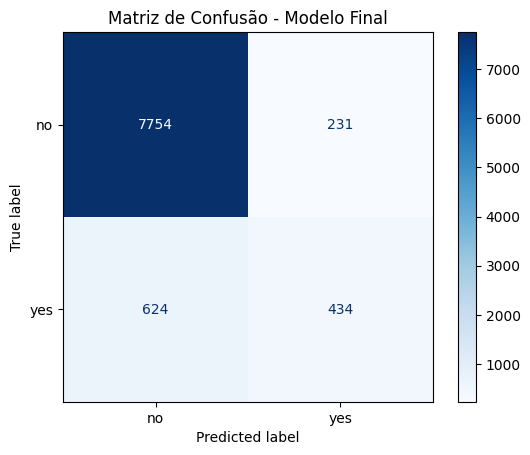


Comparação com o Baseline


,Baseline,Modelo Final
Accuracy,0.883,0.905452
F1-score,0.000,0.503772
Precision,0.000,0.652632
ROC AUC,0.500,0.924033
Recall,0.000,0.410208
Train Time (s),0.313,NaN


In [36]:
# ==========================================
# Avaliação final no conjunto de teste
# ==========================================

# Modelo final
final_model = search.best_estimator_

print("=" * 60)
print("Modelo Final")
print("=" * 60)
print(final_model)

# Previsões
y_pred = final_model.predict(X_test)

# Probabilidades
proba = final_model.predict_proba(X_test)

# Métricas
final_results = evaluate_classification(
    final_model,
    X_test,
    y_test
)

print("\nMétricas do modelo final")
display(pd.DataFrame([final_results], index=["Gradient Boosting Otimizado"]))

print("\nRelatório de Classificação")
print(classification_report(y_test, y_pred))

# Matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Modelo Final")
plt.show()

# Comparação com o baseline
comparison = pd.DataFrame({
    "Baseline": results_df.loc["Baseline"],
    "Modelo Final": pd.Series(final_results)
})

print("\nComparação com o Baseline")

display(comparison)

## 10.1 Análise de erros e limitações

A avaliação final foi conduzida usando o conjunto de teste, que é composto por dados que não foram incluídos nas fases de treinamento ou na otimização de hiperparâmetros. Essa metodologia possibilita uma estimativa mais precisa da habilidade de generalização do modelo em cenários reais.

O modelo Gradient Boosting otimizado exibiu uma acurácia de 90,55%, uma precisão de 65,26%, um recall de 41,02%, um F1-score de 0,5038 e um ROC AUC de 0,9240. Esses resultados mostram um desempenho muito melhor do que o modelo baseline, que, embora tenha uma acurácia de 88,30%, apresentou valores nulos para Precision, Recall e F1-score. Isso evidencia que o modelo baseline não consegue identificar corretamente os clientes da classe positiva.

A matriz de confusão e o relatório de classificação indicam que o modelo tem uma alta precisão na identificação de clientes que não aderem ao depósito a prazo. No entanto, ainda enfrenta desafios para identificar a parcela de clientes que realmente adere ao produto, o que se reflete em um recall de cerca de 41%. Esse comportamento é esperado devido ao desbalanceamento existente entre as classes, no qual a quantidade de clientes que aderiram à campanha é significativamente menor que a daqueles que não aderiram.

A comparação entre os resultados da validação cruzada (F1-score médio de 0,5164) e da avaliação final no conjunto de teste (F1-score de 0,5038) indica que o modelo teve um desempenho estável, sem sinais significativos de overfitting. A leve discrepância observada entre essas métricas é normal e sugere que o modelo conseguiu se adaptar de forma adequada a dados que não foram empregados durante o treinamento.

Embora tenha alcançado um bom desempenho, algumas limitações devem ser levadas em conta. A principal diz respeito ao desequilíbrio da variável-alvo, que torna mais difícil a identificação da classe positiva. Ademais, a variável duration, apesar de ter um alto poder preditivo, impõe uma restrição para aplicações práticas, uma vez que sua informação só é acessível após o contato telefônico. Isso pode resultar em vazamento de informação (data leakage) em situações de previsão que antecedem a ligação.

Como trabalhos futuros, seria interessante investigar métodos específicos para lidar com classes desbalanceadas, como SMOTE, ajuste de pesos das classes (class weights) e otimização do limiar de decisão (threshold tuning). Além disso, seria viável comparar o desempenho do Gradient Boosting com algoritmos mais novos, como XGBoost, LightGBM e CatBoost, bem como realizar uma busca mais extensa por hiperparâmetros para verificar a possibilidade de melhorias no desempenho.

# 11. Comparação final dos modelos

In [37]:
# ==========================================
# Comparação final dos modelos
# ==========================================

comparison_df = pd.DataFrame({
    "Modelo": [
        "Baseline (DummyClassifier)",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting (Otimizado)"
    ],

    "F1-score": [
        results["Baseline"]["F1-score"],
        results["Logistic Regression"]["F1-score"],
        results["Decision Tree"]["F1-score"],
        results["Random Forest"]["F1-score"],
        final_results["F1-score"]
    ],

    "Accuracy": [
        results["Baseline"]["Accuracy"],
        results["Logistic Regression"]["Accuracy"],
        results["Decision Tree"]["Accuracy"],
        results["Random Forest"]["Accuracy"],
        final_results["Accuracy"]
    ],

    "ROC AUC": [
        results["Baseline"]["ROC AUC"],
        results["Logistic Regression"]["ROC AUC"],
        results["Decision Tree"]["ROC AUC"],
        results["Random Forest"]["ROC AUC"],
        final_results["ROC AUC"]
    ],

    "Tempo de treino (s)": [
        results["Baseline"]["Train Time (s)"],
        results["Logistic Regression"]["Train Time (s)"],
        results["Decision Tree"]["Train Time (s)"],
        results["Random Forest"]["Train Time (s)"],
        results["Gradient Boosting"]["Train Time (s)"]
    ],

    "Observações": [
        "Prevê sempre a classe mais frequente.",
        "Modelo simples, interpretável e rápido.",
        "Boa interpretabilidade, porém menor capacidade de generalização.",
        "Maior ROC AUC entre os modelos avaliados.",
        "Melhor equilíbrio entre Precision, Recall e F1-score."
    ]
})

# Arredondar valores numéricos
comparison_df["F1-score"] = comparison_df["F1-score"].round(4)
comparison_df["Accuracy"] = comparison_df["Accuracy"].round(4)
comparison_df["ROC AUC"] = comparison_df["ROC AUC"].round(4)
comparison_df["Tempo de treino (s)"] = comparison_df["Tempo de treino (s)"].round(3)

display(comparison_df)

,Modelo,F1-score,Accuracy,ROC AUC,Tempo de treino (s),Observações
0,Baseline (DummyClassifier),0.0000,0.8830,0.5000,0.313,Prevê sempre a classe mais frequente.
1,Logistic Regression,0.4518,0.9012,0.9056,1.034,"Modelo simples, interpretável e rápido."
2,Decision Tree,0.4701,0.8746,0.7015,0.894,"Boa interpretabilidade, porém menor capacidade..."
3,Random Forest,0.4924,0.9045,0.9263,4.365,Maior ROC AUC entre os modelos avaliados.
4,Gradient Boosting (Otimizado),0.5038,0.9055,0.9240,9.004,"Melhor equilíbrio entre Precision, Recall e F1..."


# 12. Boas práticas e rastreabilidade

In [38]:
# ==========================================
# Registro de decisões do projeto
# ==========================================

decisions_df = pd.DataFrame({
    "Decisão": [
        "Utilizar seed fixa igual a 42",
        "Usar holdout com divisão 80/20",
        "Aplicar estratificação na divisão treino/teste",
        "Definir F1-score como métrica principal",
        "Utilizar Pipeline do Scikit-Learn",
        "Aplicar One-Hot Encoding nas variáveis categóricas",
        "Aplicar StandardScaler nas variáveis numéricas",
        "Manter a variável duration no MVP",
        "Comparar baseline com múltiplos modelos candidatos",
        "Otimizar o Gradient Boosting",
        "Limitar a busca de hiperparâmetros",
        "Manter o projeto sem bibliotecas externas adicionais"
    ],

    "Justificativa": [
        "Garantir reprodutibilidade dos experimentos.",
        "Separar dados de treino e teste para avaliar generalização.",
        "Preservar a proporção das classes em razão do desbalanceamento do target.",
        "Avaliar melhor o equilíbrio entre Precision e Recall da classe positiva.",
        "Evitar vazamento de dados e padronizar o fluxo de pré-processamento e modelagem.",
        "Permitir que variáveis categóricas sejam utilizadas pelos modelos.",
        "Reduzir diferenças de escala entre variáveis numéricas.",
        "Preservar a estrutura original do dataset, apesar do risco de data leakage em aplicações reais.",
        "Verificar se os modelos realmente aprendem padrões além da classe majoritária.",
        "Foi o modelo com melhor F1-score na avaliação inicial.",
        "Controlar tempo de execução e custo computacional, mantendo o escopo de MVP.",
        "Aumentar a reprodutibilidade e reduzir risco de incompatibilidades no ambiente."
    ],

    "Impacto esperado": [
        "Resultados consistentes em diferentes execuções.",
        "Avaliação mais confiável em dados não vistos.",
        "Evitar distorções na avaliação dos modelos.",
        "Melhor análise do desempenho na classe minoritária.",
        "Processo mais robusto, organizado e reproduzível.",
        "Transformação adequada dos atributos não numéricos.",
        "Melhor desempenho para modelos sensíveis à escala.",
        "Melhor comparação com a estrutura original da base, com limitação documentada.",
        "Definir uma referência mínima e comparar ganhos reais.",
        "Buscar melhoria de desempenho no principal candidato.",
        "Busca simples, rápida e adequada ao objetivo do trabalho.",
        "Notebook mais simples, leve e executável no Google Colab."
    ]
})

display(decisions_df)

,Decisão,Justificativa,Impacto esperado
0,Utilizar seed fixa igual a 42,Garantir reprodutibilidade dos experimentos.,Resultados consistentes em diferentes execuções.
1,Usar holdout com divisão 80/20,Separar dados de treino e teste para avaliar g...,Avaliação mais confiável em dados não vistos.
2,Aplicar estratificação na divisão treino/teste,Preservar a proporção das classes em razão do ...,Evitar distorções na avaliação dos modelos.
3,Definir F1-score como métrica principal,Avaliar melhor o equilíbrio entre Precision e ...,Melhor análise do desempenho na classe minorit...
4,Utilizar Pipeline do Scikit-Learn,Evitar vazamento de dados e padronizar o fluxo...,"Processo mais robusto, organizado e reproduzível."
5,Aplicar One-Hot Encoding nas variáveis categór...,Permitir que variáveis categóricas sejam utili...,Transformação adequada dos atributos não numér...
6,Aplicar StandardScaler nas variáveis numéricas,Reduzir diferenças de escala entre variáveis n...,Melhor desempenho para modelos sensíveis à esc...
7,Manter a variável duration no MVP,"Preservar a estrutura original do dataset, ape...",Melhor comparação com a estrutura original da ...
8,Comparar baseline com múltiplos modelos candid...,Verificar se os modelos realmente aprendem pad...,Definir uma referência mínima e comparar ganho...
9,Otimizar o Gradient Boosting,Foi o modelo com melhor F1-score na avaliação ...,Buscar melhoria de desempenho no principal can...


# 13. Conclusão

O objetivo deste estudo foi criar e analisar modelos de Machine Learning que possam prever a adesão de clientes a depósitos a prazo, com base em dados demográficos, financeiros e históricos de campanhas de marketing. A proposta procurou mostrar como as técnicas de classificação supervisionada podem ajudar as instituições financeiras a direcionar campanhas de marketing de maneira mais eficaz, focando nos clientes com maior chance de conversão.

Durante o desenvolvimento do MVP, todas as fases de um projeto de Ciência de Dados foram executadas, desde a análise exploratória e preparação dos dados até a construção de pipelines de pré-processamento, treinamento de diversos algoritmos, otimização de hiperparâmetros e avaliação final em um conjunto de teste independente. A adoção de boas práticas, como a divisão estratificada dos dados, validação cruzada e uso de pipelines do Scikit-Learn, ajudou a assegurar a reprodutibilidade do projeto e a minimizar o risco de vazamento de dados (data leakage).

Dentre os modelos analisados, o Gradient Boosting exibiu o melhor desempenho em relação ao F1-score, que foi estabelecido como o principal critério de avaliação em razão do desbalanceamento da variável-alvo. O modelo otimizado alcançou uma acurácia de 90,55%, precisão de 65,26%, recall de 41,02%, F1-score de 0,5038 e ROC AUC de 0,9240, superando significativamente o modelo baseline. Embora este último tenha exibido uma alta acurácia, ele não conseguiu identificar corretamente os clientes da classe positiva.

Os resultados obtidos mostram que o uso de algoritmos de Machine Learning pode ajudar de forma eficaz na tomada de decisões em campanhas de marketing bancário. A identificação antecipada de clientes com maior probabilidade de adesão possibilita um melhor direcionamento dos recursos da instituição, diminuindo os custos operacionais e otimizando a eficácia das estratégias comerciais.

Embora os resultados sejam satisfatórios, algumas limitações devem ser levadas em consideração. A base de dados exibe um desbalanceamento entre as classes e inclui a variável duration (está variável foi mantida para preservação da estrutura original e para comparação dos estudos existentes, em aplicação real antes do contato com o cliente, essa deverá ser removida), que possui um alto poder preditivo, mas constitui uma restrição para aplicações práticas, uma vez que sua informação só é acessível após o contato telefônico com o cliente. Ademais, a otimização de hiperparâmetros foi executada em um conjunto limitado de combinações, alinhado ao escopo de um MVP e ao tempo disponível para a execução.

Como trabalhos futuros, recomenda-se ampliar a busca de hiperparâmetros, avaliar técnicas para tratamento de classes desbalanceadas, como SMOTE, ajuste de pesos das classes e otimização do limiar de decisão (threshold tuning), além de comparar o desempenho do Gradient Boosting com algoritmos mais recentes, como XGBoost, LightGBM e CatBoost. Essas abordagens podem contribuir para melhorar ainda mais a capacidade preditiva do modelo e ampliar sua aplicação em cenários reais.

O modelo criado demonstrou um desempenho estável durante as fases de validação e avaliação final, mostrando uma sólida capacidade de generalização e potencial para auxiliar na tomada de decisões estratégicas em campanhas de marketing bancário fundamentadas em dados.

# 14. Salvamento de artefatos




In [39]:
# ==========================================
# Salvamento dos artefatos do projeto
# ==========================================

import joblib

# Salvar o modelo final
if final_model is not None:
    joblib.dump(final_model, "modelo_final.pkl")
    print("✔ Modelo salvo como 'modelo_final.pkl'.")

# Salvar a tabela de resultados dos modelos
results_df.to_csv("resultados_modelos.csv", index=True)
print("✔ Tabela de resultados salva como 'resultados_modelos.csv'.")

# Salvar a tabela comparativa final
comparison_df.to_csv("comparacao_modelos.csv", index=False)
print("✔ Comparação dos modelos salva como 'comparacao_modelos.csv'.")

print("\nArtefatos salvos com sucesso!")

✔ Modelo salvo como 'modelo_final.pkl'.
✔ Tabela de resultados salva como 'resultados_modelos.csv'.
✔ Comparação dos modelos salva como 'comparacao_modelos.csv'.

Artefatos salvos com sucesso!


Durante o desenvolvimento deste MVP foi possível aplicar todas as principais etapas de um projeto de Ciência de Dados, desde a compreensão do problema de negócio até a construção e avaliação de modelos de Machine Learning. O projeto demonstrou que a utilização de modelos preditivos pode contribuir para tornar campanhas de marketing mais eficientes, direcionando esforços para clientes com maior probabilidade de adesão ao produto. Além disso, foram adotadas boas práticas de reprodutibilidade, documentação e prevenção de vazamento de dados, tornando o notebook executável e facilmente reproduzível.